Predicting Respiratory Syncytial Virus (RSV) infection rates for the entire population (all age groups and genders) of Silesia for Week 17, 2026. The model is trained on public healthcare data from the ezdrowie.gov.pl portal (January 2024 – April 2026), utilizing the incidence rate per 100,000 inhabitants

$ \textbf{Data Ingestion \& Preprocessing:} \newline$
Data was extracted from the Arkusz1 sheet of the ABC.xlsx file. $\newline$
The initial row was omitted as it contained column headers. $\newline$
The following columns were utilized for the analysis: year, week number, and the number of reported cases. $\newline$
The dataset was subsequently sorted in chronological order. $\newline$

$ \textbf{Forecasting Model:}\newline$
A first-order difference equation was implemented:$\newline$
$$y_t = a \cdot y_{t-1} + b$$
The model parameters were estimated utilizing Ordinary Linear Regression. $\newline$

$ \textbf{Parameter Interpretation:}\newline$
Coefficient $a$ represents the autoregressive dependency on the preceding week's incidence. $\newline$
Coefficient $b$ accounts for the constant baseline rate of growth or decline. $\newline$

$ \textbf{Forecast:}\newline$
The future projection was computed sequentially based on the most recent available data point:$\newline$
$$y_{t+1} = a \cdot y_t + b$$

$ \textbf{Data Ingestion \& Preprocessing:} \newline$
The `pandas` library was imported for data manipulation. $\newline$
The `numpy` library was imported for numerical computations. $\newline$
The `sklearn` library was imported for machine learning modeling. $\newline$
A library for creating visualizations (e.g., `matplotlib`) was imported. $\newline$

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

$ \textbf{Data Ingestion \& Preprocessing:} \newline$
Data was extracted from the `Sheet1` sheet of the `ABC.xlsx` file. $\newline$
The initial row was omitted as it contained column headers. $\newline$
The following columns were utilized for the analysis: year, week number, and the number of reported cases. $\newline$
The dataset was subsequently sorted in chronological order. $\newline$

In [5]:
df = pd.read_excel(
    "ABC.xlsx",
    sheet_name="Sheet1",
    skiprows=1,
    header=None
)

$ \textbf{Data Ingestion \& Preprocessing:} \newline$
We select only the required columns for the analysis: $\newline$
Column 2 $\rightarrow$ index 1 (Year) $\newline$
Column 3 $\rightarrow$ index 2 (Week Number) $\newline$
Column 5 $\rightarrow$ index 4 (Number of Cases) $\newline$

In [6]:
df = df[[1, 2, 4]]

$ \textbf{Data Ingestion \& Preprocessing:} \newline$
We assign clear, descriptive names to the extracted columns. $\newline$
Any rows containing missing values (NaNs) are removed to ensure data integrity. $\newline$
The dataset is sorted chronologically, prioritizing the 'year' column followed by the 'week' column. $\newline$
Finally, we display the processed dataframe. $\newline$

In [8]:
df.columns = ["year", "week", "Number of Cases"]
df = df.dropna()
df = df.sort_values(by=["year", "week"])
df

,year,week,Number of Cases
0,2024,1,14.669091
1,2024,2,17.280094
2,2024,3,24.970686
3,2024,4,26.062560
4,2024,5,23.736393
...,...,...,...
113,2026,11,27.605425
114,2026,12,25.279259
115,2026,13,23.048038
116,2026,14,17.992186


$ \textbf{Data Ingestion \& Preprocessing:} \newline$
We extract the number of cases as a numerical vector. $\newline$
Next, we prepare the data structure for the difference equation model: $\newline$
$y_{prev}$ - represents the incidence values from the preceding week (lagged by 1). $\newline$
$y_{curr}$ - represents the incidence values from the current week. $\newline$

In [9]:
y = df["Number of Cases"].values
y_prev = y[:-1].reshape(-1, 1)
y_curr = y[1:]

$ \textbf{Data Ingestion \& Preprocessing:} \newline$
We fit a first-order difference equation model: $\newline$
$$y_t = a \cdot y_{t-1} + b$$
The model coefficients are then extracted. $\newline$
Finally, the estimated parameters are displayed. $\newline$

In [10]:
model = LinearRegression()
model.fit(y_prev, y_curr)


a = model.coef_[0]
b = model.intercept_


print("Coefficient a:", a)
print("Coefficient b:", b)

Coefficient a: 0.9636136336546105
Coefficient b: 0.24322554990809842


$ \textbf{Data Ingestion \& Preprocessing:} \newline$
We project the forecast for the upcoming weeks (up to Week 17 of 2026, using data available through Week 14). $\newline$
The computation is initialized using the most recent observed value. $\newline$
The incidence rate is calculated iteratively. $\newline$
Finally, the projected value is rounded and displayed. $\newline$

In [11]:
y_last = y[-1]
y_15 = a * y_last + b
y_16 = a * y_15 + b
y_17 = a * y_16 + b
forecast = a * y_17 + b
forecast_1 = round(forecast,1)

print("Forecast:", forecast_1)

Forecast: 10.0


$ \textbf{Data Visualization:} \newline$
We generate x-axis labels structured in a "year-week" format. $\newline$
A time-series plot is constructed to visualize the historical incidence data alongside the projected forecast. $\newline$
The forecasted data point is explicitly highlighted on the graph. $\newline$
The x-axis tick intervals are configured to display every 10 weeks for optimal readability. $\newline$
Comprehensive plot annotations (title, axis labels, and legend) are incorporated. $\newline$
Finally, the visualization is rendered. $\newline$

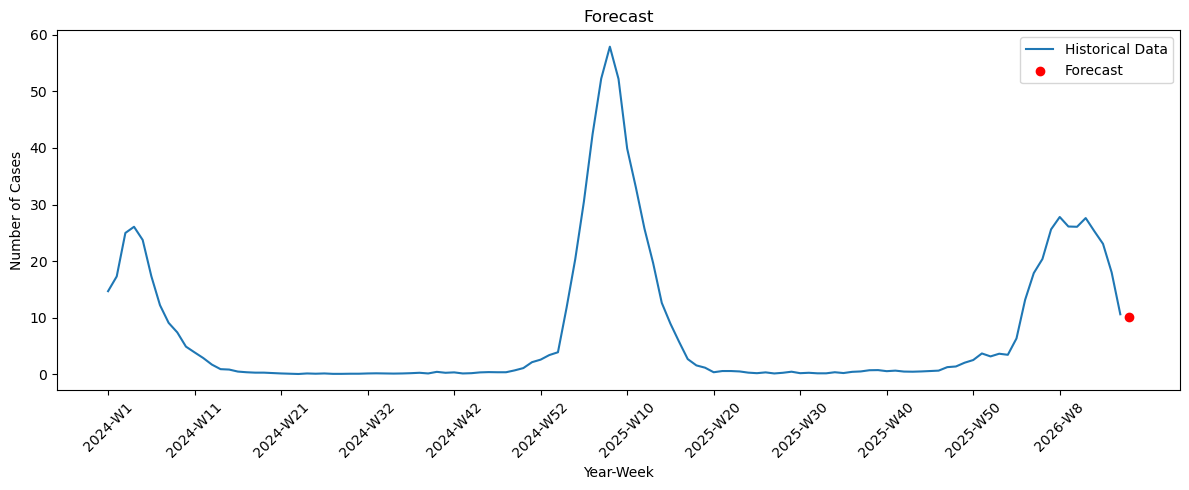

In [13]:
labels = df["year"].astype(int).astype(str) + "-W" + df["week"].astype(int).astype(str)


plt.figure(figsize=(12, 5))
plt.plot(range(len(y)), y, label="Historical Data")


plt.scatter(len(y), forecast, color="red", label="Forecast")


tick_positions = list(range(0, len(labels), 10))
tick_labels = labels.iloc[tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45)


plt.legend()
plt.title("Forecast")
plt.xlabel("Year-Week")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.show()